In [1]:
# # Only to be used in colab environment

# from google.colab import drive
# drive.mount('/content/drive')

# %cd /content/drive/MyDrive/a3_sectC_train
# !pwd

Run the preprocessing notebook to generate the "zqq_flavor.h5" and "zqq_flavor_v2.h5" to be  used in this notebook

In [2]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.layers import (Input, Masking, Dense, Dropout,
                                     Layer, LayerNormalization,
                                     GlobalAveragePooling1D, MultiHeadAttention,
                                     Conv1D, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import wandb
from wandb.integration.keras import WandbCallback

from src.model import build_transformer
from src.dataloader import HDF5DataLoader


In [3]:
# Checking GPU information
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    print("No GPU available. Using CPU.")
else:
    print("GPU(s) available:")
    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        print("Name:", gpu.name)
        print("Details:", details)

No GPU available. Using CPU.


# Use data with Particle_ID and Particle_orivtx_ind

In [4]:
# --------------------------------------------
# reate Data Loaders
# --------------------------------------------
train_loader = HDF5DataLoader('dataset/zqq_flavor.h5', 'train', batch_size=512, shuffle=True)
val_loader   = HDF5DataLoader('dataset/zqq_flavor.h5', 'val',   batch_size=512, shuffle=False)
test_loader  = HDF5DataLoader('dataset/zqq_flavor.h5', 'test',  batch_size=512, shuffle=False)

In [5]:
# --------------------------------------------
# 5. Build Model
# --------------------------------------------
model = build_transformer(
    num_layers=4,
    d_model=64,
    num_heads=6,
    d_ff=128,
    dropout_rate=0.05,
    max_particles=35,
    max_vertices=5,
    nParFeatures=14,
    nVerFeatures=8)

model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model.summary()

Model: "TransformerFlavorTagger"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ particle_input      │ (None, 35, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vertex_input        │ (None, 5, 8)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 35, 14)    │          0 │ particle_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ particle_mask       │ (None, 35)        │          0 │ particle_input[0… │
│ (ParticleMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vertex_mask         │ (None, 5)         │          0 │ vertex_input[0][… │
│ (VertexMask)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_particle      │ (None, 35, 64)    │        960 │ masking[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_vertex        │ (None, 5, 64)     │        576 │ vertex_input[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40)        │          0 │ particle_mask[0]… │
│ (Concatenate)       │                   │            │ vertex_mask[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_particles_v… │ (None, 40, 64)    │          0 │ embed_particle[0… │
│ (Concatenate)       │                   │            │ embed_vertex[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_layer   │ (None, 1, 40)     │          0 │ concatenate[0][0] │
│ (ExpandDimsLayer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_0     │ (None, 40, 64)    │    116,352 │ concat_particles… │
│ (TransformerEncode… │                   │            │ expand_dims_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_1     │ (None, 40, 64)    │    116,352 │ encoder_layer_0[… │
│ (TransformerEncode… │                   │            │ expand_dims_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_2     │ (None, 40, 64)    │    116,352 │ encoder_layer_1[… │
│ (TransformerEncode… │                   │            │ expand_dims_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_3     │ (None, 40, 64)    │    116,352 │ encoder_layer_2[… │
│ (TransformerEncode… │                   │            │ expand_dims_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_aggregator     │ (None, 40, 32)    │      6,176 │ encoder_layer_3[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling             │ (None, 32)        │          0 │ conv_aggregator[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_head (Dense)  │ (None, 64)        │      2,112 │ pooling[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 475,427 (1.81 MB)

 Trainable params: 475,427 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# # --------------------------------------------
# # Train With wandb
# # --------------------------------------------

# import wandb
# from wandb.integration.keras import WandbCallback

# if not os.path.exists("results/model"):
#     os.makedirs("results/model")

# wandb.init(project="my-transformer-project", name="experiment_01")

# # Early stopping
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # Load the model saved in the native Keras format (.keras)
# model_checkpoint = ModelCheckpoint(
#     filepath="results/model/best_model.keras",  # Use the new native Keras format
#     monitor='val_loss',
#     save_best_only=True)

# train_dataset = train_loader.get_dataset()
# val_dataset = val_loader.get_dataset()
# history = model.fit(train_dataset,
#     validation_data=val_dataset,
#     epochs=50,
#     callbacks=[WandbCallback(save_graph=False, save_model=False),
#         early_stopping,
#         model_checkpoint])
# hist_dict = history.history

# hist_df = pd.DataFrame(hist_dict)

# # save training history to results
# hist_df.to_csv("results/training_history.csv", index=False)

In [7]:
# --------------------------------------------
# Load model and see performance on test set
# --------------------------------------------

model = tf.keras.models.load_model("results/model/best_model.keras")
# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_loader)
print("Test Accuracy =", test_acc)

c:\Users\woyao\miniconda3\envs\a3_cw\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 196ms/step - accuracy: 0.9091 - loss: 0.2625
Test Accuracy = 0.9089778065681458


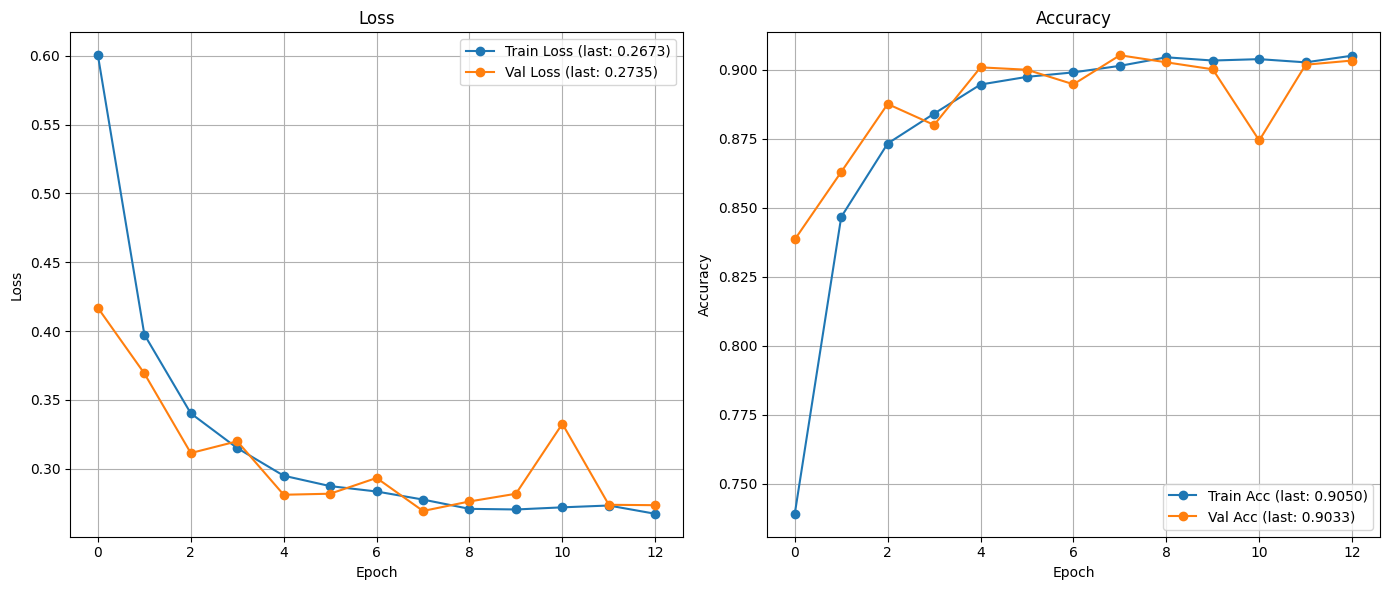

In [8]:
# Plot loss and accuracy

hist_df = pd.read_csv("results/training_history.csv")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot loss curve
axes[0].plot(hist_df['loss'], label=f"Train Loss (last: {hist_df['loss'].iloc[-1]:.4f})", marker='o')
axes[0].plot(hist_df['val_loss'], label=f"Val Loss (last: {hist_df['val_loss'].iloc[-1]:.4f})", marker='o')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Plot accuracy curve
axes[1].plot(hist_df['accuracy'], label=f"Train Acc (last: {hist_df['accuracy'].iloc[-1]:.4f})", marker='o')
axes[1].plot(hist_df['val_accuracy'], label=f"Val Acc (last: {hist_df['val_accuracy'].iloc[-1]:.4f})", marker='o')
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [9]:
# This block processes the train, validation, and test datasets for each flavor (Zbb, Zss, Zcc):
# 1. It defines a filter function that retains only samples whose true label matches the given target index.
# 2. For each flavor, it unbatches the datasets, filters them using the filter function, and then re-batches them.
# 3. It computes predictions on these filtered datasets and extracts the predicted probability for the corresponding flavor.
# 4. Finally, it stores the filtered datasets, raw predictions, and extracted probabilities in the dictionary 'pred_info'
#    for later analysis such as plotting histograms or calculating confusion matrices.


flavor_map = {'Zbb': 0, 'Zss': 1, 'Zcc': 2}

train_dataset = train_loader.get_dataset()
val_dataset = val_loader.get_dataset()
test_dataset = test_loader.get_dataset()

# Define a function to return filter function for a given target index.
def get_filter_func(target):
    return lambda x, y: tf.equal(tf.argmax(y, axis=-1), target)

# Define batch size for filtering.
batch_size_filter = 1000

# Initialize a dictionary to store prediction information for each flavor.
pred_info = {}

# Loop over each flavor, filter the datasets, and compute predictions.
for flavor, target in flavor_map.items():
    # Get filter function for the current flavor.
    filter_func = get_filter_func(target)

    # Filter samples from train, validation, and test datasets and batch them.
    flavor_train_dataset = train_dataset.unbatch().filter(filter_func).batch(batch_size_filter)
    flavor_val_dataset   = val_dataset.unbatch().filter(filter_func).batch(batch_size_filter)
    flavor_test_dataset  = test_dataset.unbatch().filter(filter_func).batch(batch_size_filter)

    # Get predictions for the filtered samples.
    train_preds = model.predict(flavor_train_dataset)
    val_preds   = model.predict(flavor_val_dataset)
    test_preds  = model.predict(flavor_test_dataset)

    # Extract the predicted probability for the target flavor index.
    train_probs = train_preds[:, target]
    val_probs   = val_preds[:, target]
    test_probs  = test_preds[:, target]

    # Store all necessary prediction information in the dictionary.
    pred_info[flavor] = {
        'flavor_train_dataset': flavor_train_dataset,
        'flavor_val_dataset': flavor_val_dataset,
        'flavor_test_dataset': flavor_test_dataset,
        'train_preds': train_preds,
        'val_preds': val_preds,
        'test_preds': test_preds,
        'train_probs': train_probs,
        'val_probs': val_probs,
        'test_probs': test_probs}


50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 464ms/step


c:\Users\woyao\miniconda3\envs\a3_cw\lib\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 418ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 483ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 489ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 430ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 426ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 432ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 377ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 374ms/step


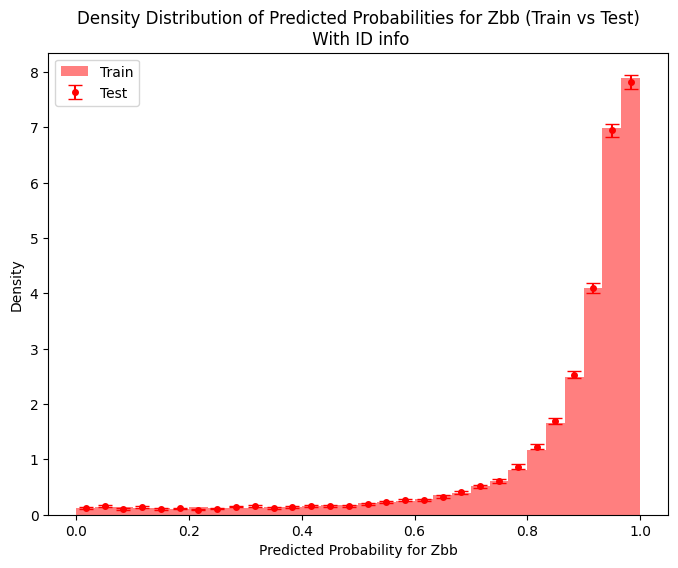

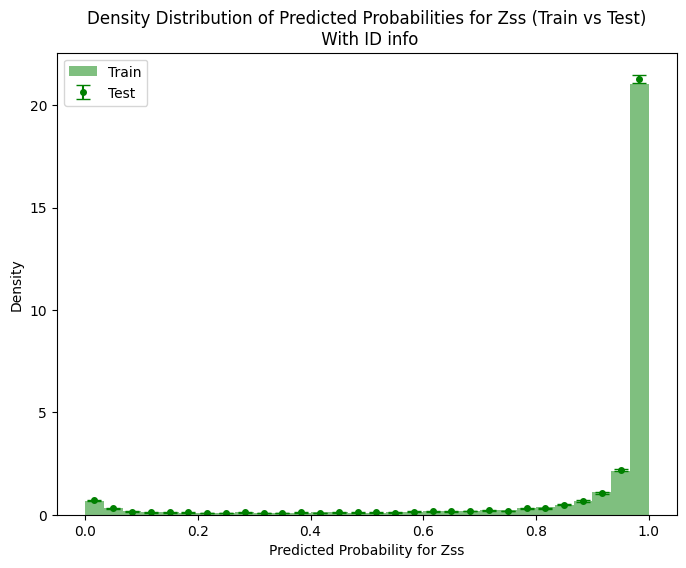

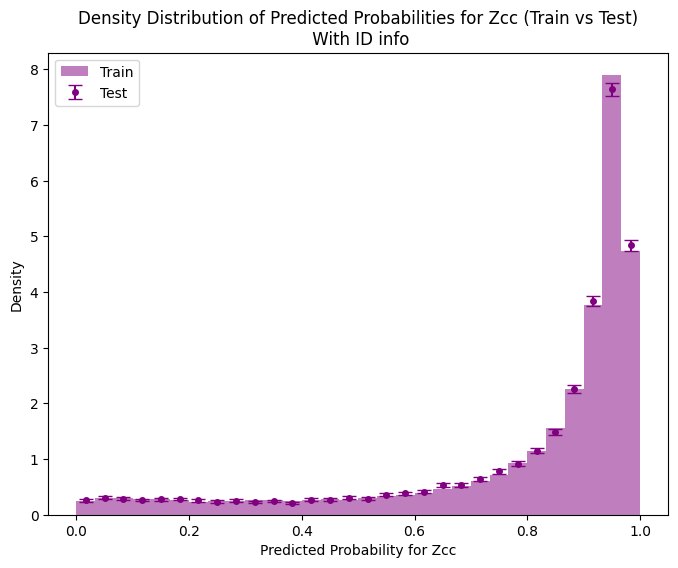

In [10]:
def plot_flavor_histograms(pred_info, bins, color_dict, version):

    for flavor, info in pred_info.items():

        train_probs = info['train_probs']
        test_probs = info['test_probs']

        train_counts, bin_edges = np.histogram(train_probs, bins=bins)
        test_counts, _ = np.histogram(test_probs, bins=bins)


        n_train = len(train_probs)
        n_test = len(test_probs)
        bin_width = bin_edges[1] - bin_edges[0]

        # density = count / (total_samples * bin_width)
        train_density = train_counts / (n_train * bin_width)
        test_density = test_counts / (n_test * bin_width)

        # Poisson error = sqrt(count) / (total_samples * bin_width)
        train_errors = np.sqrt(train_counts) / (n_train * bin_width)
        test_errors = np.sqrt(test_counts) / (n_test * bin_width)

        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        color = color_dict.get(flavor, 'blue')

        plt.figure(figsize=(8, 6))
        plt.bar(bin_centers, train_density, width=bin_width, color=color, alpha=0.5, label='Train')
        plt.errorbar(bin_centers, test_density, yerr=test_errors, fmt='o', color=color, markersize=4, capsize=5, label='Test')
        plt.xlabel(f'Predicted Probability for {flavor}')
        plt.ylabel('Density')
        plt.title(f'Density Distribution of Predicted Probabilities for {flavor} (Train vs Test)\n {version}')
        plt.legend()
        plt.show()


bins = np.linspace(0, 1, 31)

color_dict = {'Zbb': 'red', 'Zss': 'green', 'Zcc': 'purple'}

plot_flavor_histograms(pred_info, bins, color_dict, "With ID info")


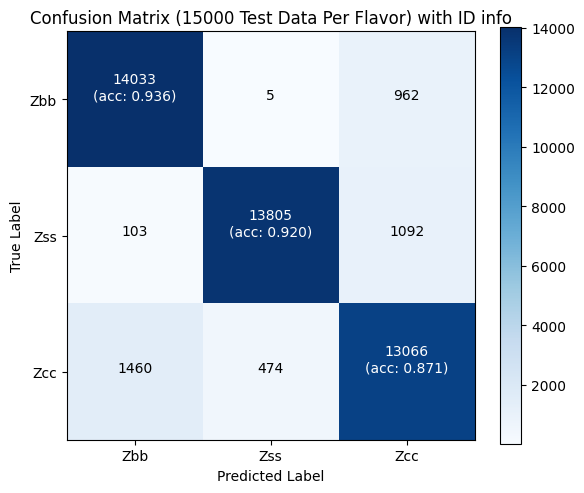

In [11]:
def plot_confusion_matrix_from_pred_info(pred_info, version):
    """
    This function constructs and plots the confusion matrix using the test predictions
    stored in the pred_info dictionary. It assumes that for each flavor, the test dataset
    has been filtered so that all true labels are the same (the target index for that flavor).

    The function:
    1. Iterates over each flavor in pred_info.
    2. For each flavor, it computes the predicted labels from the test predictions (using np.argmax)
       and creates an array of true labels (all equal to the flavor's target index).
    3. It combines all true and predicted labels across flavors.
    4. Computes the confusion matrix using sklearn.metrics.confusion_matrix.
    5. Plots the confusion matrix with color coding and text annotations, and on the diagonal,
       additionally displays the per-class accuracy (value/15000).
    """

    # Define local flavor mapping (should match the original mapping)
    flavor_map_local = {'Zbb': 0, 'Zss': 1, 'Zcc': 2}

    # Initialize lists to collect true and predicted labels
    y_true_all = []
    y_pred_all = []

    # Loop over each flavor and gather true and predicted labels from test predictions.
    for flavor, info in pred_info.items():
        true_label = flavor_map_local[flavor]
        test_preds = info['test_preds']  # shape: (n_samples, num_classes)
        # Compute predicted labels using argmax over the class dimension.
        predicted_labels = np.argmax(test_preds, axis=1)
        # Create an array of true labels for this flavor.
        true_labels = np.full_like(predicted_labels, fill_value=true_label)

        # Append to the overall lists.
        y_true_all.extend(true_labels.tolist())
        y_pred_all.extend(predicted_labels.tolist())

    # Convert lists to numpy arrays.
    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    # Compute the confusion matrix.
    cm = confusion_matrix(y_true_all, y_pred_all)

    # Plot the confusion matrix.
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix (15000 Test Data Per Flavor) {version}')
    plt.colorbar()
    classes = ['Zbb', 'Zss', 'Zcc']
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # Add text annotations to each cell.
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            cell_text = format(cm[i, j], 'd')
            # On the diagonal, append the per-class accuracy (cell value / 15000)
            if i == j:
                acc = cm[i, j] / 15000.0
                cell_text += f"\n(acc: {acc:.3f})"
            plt.text(j, i, cell_text,
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()



plot_confusion_matrix_from_pred_info(pred_info, 'with ID info')

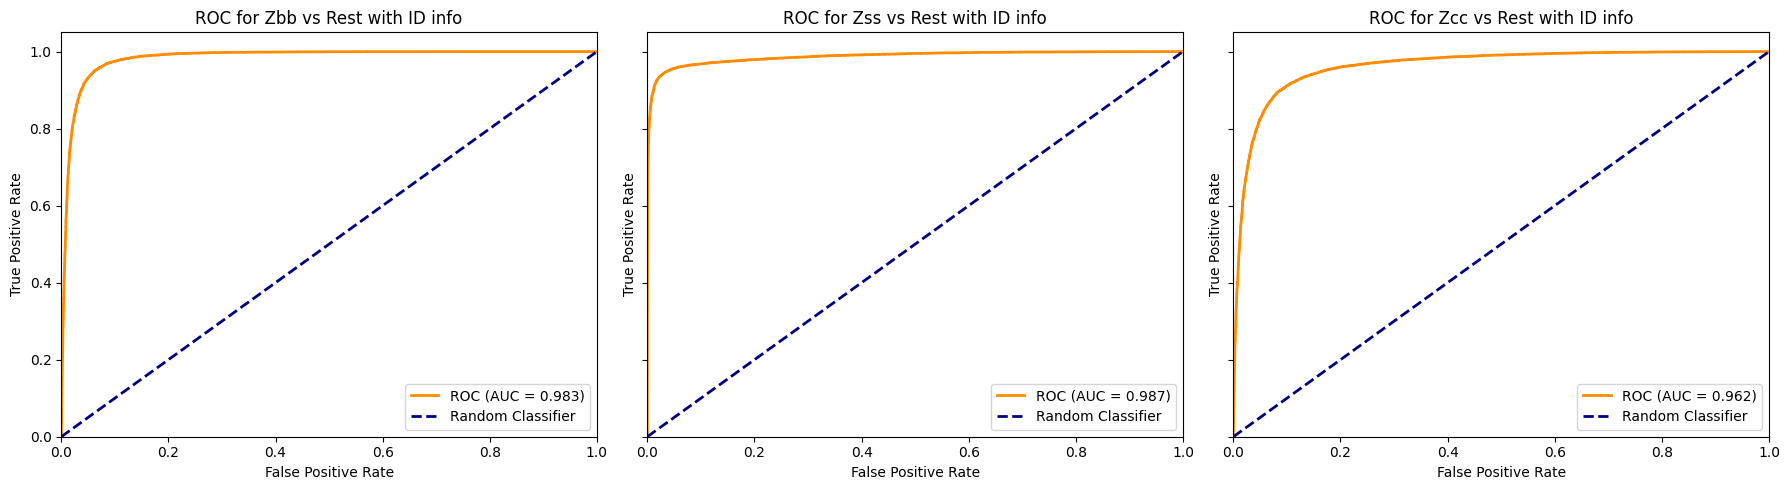

In [12]:
def plot_roc_curves(pred_info, flavor_map, version=""):
    """
    For each flavor in flavor_map, this function computes the ROC curve and AUC
    for a one-vs-rest setting using the test predictions stored in pred_info, and
    then plots all ROC curves side by side in a single figure.

    Parameters:
      pred_info: dict, containing keys for each flavor with test_preds (raw predictions)
      flavor_map: dict, mapping flavor names to target indices (e.g., {'Zbb': 0, 'Zss': 1, 'Zcc': 2})
      version: str, an optional version string to include in each subplot's title.
    """

    flavors = list(flavor_map.keys())
    n_flavors = len(flavors)

    fig, axs = plt.subplots(1, n_flavors, figsize=(6 * n_flavors, 5), sharex=True, sharey=True)

    if n_flavors == 1:
        axs = [axs]

    for i, flavor in enumerate(flavors):
        target = flavor_map[flavor]
        # Positive samples from current flavor test predictions.
        pos_probs = pred_info[flavor]['test_probs']
        pos_true = np.ones_like(pos_probs)

        # Negative samples: collect the probability at the current flavor index from other flavors.
        neg_probs_list = []
        for other_flavor in flavors:
            if other_flavor != flavor:
                other_test_preds = pred_info[other_flavor]['test_preds']
                neg_probs_list.append(other_test_preds[:, target])
        neg_probs = np.concatenate(neg_probs_list, axis=0) if neg_probs_list else np.array([])
        neg_true = np.zeros_like(neg_probs)

        # Combine positive and negative samples.
        all_probs = np.concatenate([pos_probs, neg_probs], axis=0)
        all_true = np.concatenate([pos_true, neg_true], axis=0)

        # Compute ROC curve and AUC.
        fpr, tpr, _ = roc_curve(all_true, all_probs)
        roc_auc = auc(fpr, tpr)

        ax = axs[i]
        ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
        # Add a label for the random classifier baseline.
        ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC for {flavor} vs Rest {version}')
        ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

plot_roc_curves(pred_info, flavor_map, version="with ID info")

# Use data without Particle_ID and Particle_orivtx_ind

In [13]:
# -------------------------------
# Create dataloader for hdf5 without particle id info
# -------------------------------
dataset_name = 'dataset/zqq_flavor_v2.h5'
train_loader_v2 = HDF5DataLoader(dataset_name, 'train', batch_size=512, shuffle=True)
val_loader_v2   = HDF5DataLoader(dataset_name, 'val', batch_size=512, shuffle=False)
test_loader_v2  = HDF5DataLoader(dataset_name, 'test', batch_size=512, shuffle=False)


In [14]:
# -------------------------------
# Construct transformer
# -------------------------------
model_v2 = build_transformer(
    num_layers=4,
    d_model=64,
    num_heads=6,
    d_ff=128,
    dropout_rate=0.05,
    max_particles=35,
    max_vertices=5,
    nParFeatures=12,
    nVerFeatures=8) # either 7, or 6
model_v2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
model_v2.summary()

Model: "TransformerFlavorTagger"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ particle_input      │ (None, 35, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vertex_input        │ (None, 5, 8)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 35, 12)    │          0 │ particle_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ particle_mask_1     │ (None, 35)        │          0 │ particle_input[0… │
│ (ParticleMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vertex_mask_1       │ (None, 5)         │          0 │ vertex_input[0][… │
│ (VertexMask)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_particle      │ (None, 35, 64)    │        832 │ masking_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_vertex        │ (None, 5, 64)     │        576 │ vertex_input[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 40)        │          0 │ particle_mask_1[… │
│ (Concatenate)       │                   │            │ vertex_mask_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_particles_v… │ (None, 40, 64)    │          0 │ embed_particle[0… │
│ (Concatenate)       │                   │            │ embed_vertex[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_layer_1 │ (None, 1, 40)     │          0 │ concatenate_3[0]… │
│ (ExpandDimsLayer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_0     │ (None, 40, 64)    │    116,352 │ concat_particles… │
│ (TransformerEncode… │                   │            │ expand_dims_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_1     │ (None, 40, 64)    │    116,352 │ encoder_layer_0[… │
│ (TransformerEncode… │                   │            │ expand_dims_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_2     │ (None, 40, 64)    │    116,352 │ encoder_layer_1[… │
│ (TransformerEncode… │                   │            │ expand_dims_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_3     │ (None, 40, 64)    │    116,352 │ encoder_layer_2[… │
│ (TransformerEncode… │                   │            │ expand_dims_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_aggregator     │ (None, 40, 32)    │      6,176 │ encoder_layer_3[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling             │ (None, 32)        │          0 │ conv_aggregator[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_head (Dense)  │ (None, 64)        │      2,112 │ pooling[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 475,299 (1.81 MB)

 Trainable params: 475,299 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# # -------------------------------
# # Train model
# # -------------------------------
# if not os.path.exists("results/model"):
#     os.makedirs("results/model")

# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# model_checkpoint = ModelCheckpoint(filepath="results/model/best_model_v2.keras",
#                                      monitor='val_loss',
#                                      save_best_only=True)

# wandb.init(project="my-transformer-project", name="experiment_v2")
# callbacks = [early_stopping, model_checkpoint]

# train_dataset_v2 = train_loader_v2.get_dataset()
# val_dataset_v2 = val_loader_v2.get_dataset()

# history_v2 = model_v2.fit(train_dataset_v2,
#                           validation_data=val_dataset_v2,
#                           epochs=50,
#                           callbacks=callbacks)

# # save training history to csv
# hist_df_v2 = pd.DataFrame(history_v2.history)
# if not os.path.exists("results"):
#     os.makedirs("results")
# hist_df_v2.to_csv("results/training_history_v2.csv", index=False)

In [16]:
model_v2 = tf.keras.models.load_model("results/model/best_model_v2.keras")
# Evaluate the model on the test dataset
test_loss, test_acc = model_v2.evaluate(test_loader_v2)
print("Test Accuracy =", test_acc)

c:\Users\woyao\miniconda3\envs\a3_cw\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 254ms/step - accuracy: 0.9260 - loss: 0.1906
Test Accuracy = 0.9269999861717224


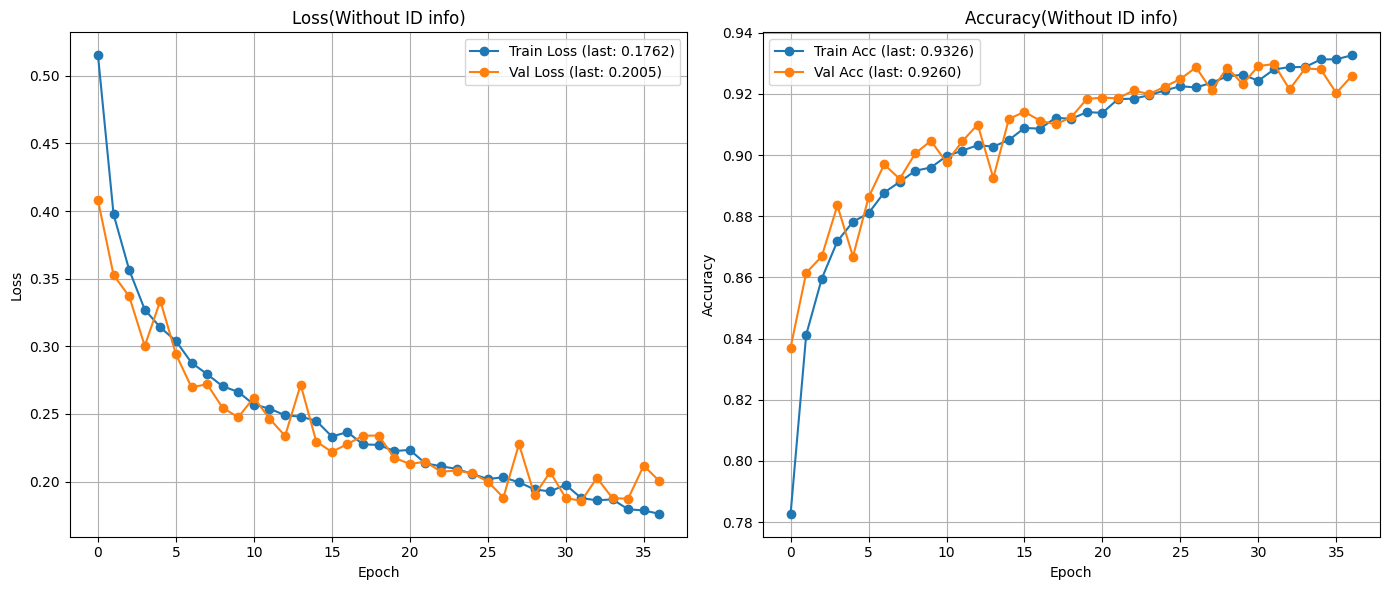

In [17]:
# -------------------------------
# Plot history curve
# -------------------------------

hist_df_v2 = pd.read_csv("results/training_history_v2.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(hist_df_v2['loss'], marker='o', label=f"Train Loss (last: {hist_df_v2['loss'].iloc[-1]:.4f})")
axes[0].plot(hist_df_v2['val_loss'], marker='o', label=f"Val Loss (last: {hist_df_v2['val_loss'].iloc[-1]:.4f})")
axes[0].set_title("Loss(Without ID info)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)
axes[1].plot(hist_df_v2['accuracy'], marker='o', label=f"Train Acc (last: {hist_df_v2['accuracy'].iloc[-1]:.4f})")
axes[1].plot(hist_df_v2['val_accuracy'], marker='o', label=f"Val Acc (last: {hist_df_v2['val_accuracy'].iloc[-1]:.4f})")
axes[1].set_title("Accuracy(Without ID info)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [18]:
# -------------------------------
# 5. Deal with each floavor
# -------------------------------

flavor_map = {'Zbb': 0, 'Zss': 1, 'Zcc': 2} # flavor mapping

# load dataset
train_dataset_v2 = train_loader_v2.get_dataset()
val_dataset_v2   = val_loader_v2.get_dataset()
test_dataset_v2  = test_loader_v2.get_dataset()

In [19]:
atch_size_filter = 1000
pred_info_v2 = {}

for flavor, target in flavor_map.items():
    filter_func = get_filter_func(target)

    flavor_train_dataset = train_dataset_v2.unbatch().filter(filter_func).batch(batch_size_filter)
    flavor_val_dataset   = val_dataset_v2.unbatch().filter(filter_func).batch(batch_size_filter)
    flavor_test_dataset  = test_dataset_v2.unbatch().filter(filter_func).batch(batch_size_filter)

    train_preds = model_v2.predict(flavor_train_dataset)
    val_preds   = model_v2.predict(flavor_val_dataset)
    test_preds  = model_v2.predict(flavor_test_dataset)

    # extract corresponding flavor probability
    train_probs = train_preds[:, target]
    val_probs   = val_preds[:, target]
    test_probs  = test_preds[:, target]

    pred_info_v2[flavor] = {
        'flavor_train_dataset': flavor_train_dataset,
        'flavor_val_dataset': flavor_val_dataset,
        'flavor_test_dataset': flavor_test_dataset,
        'train_preds': train_preds,
        'val_preds': val_preds,
        'test_preds': test_preds,
        'train_probs': train_probs,
        'val_probs': val_probs,
        'test_probs': test_probs}

50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 573ms/step


c:\Users\woyao\miniconda3\envs\a3_cw\lib\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 556ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 559ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 580ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 536ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 571ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 566ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 545ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 550ms/step


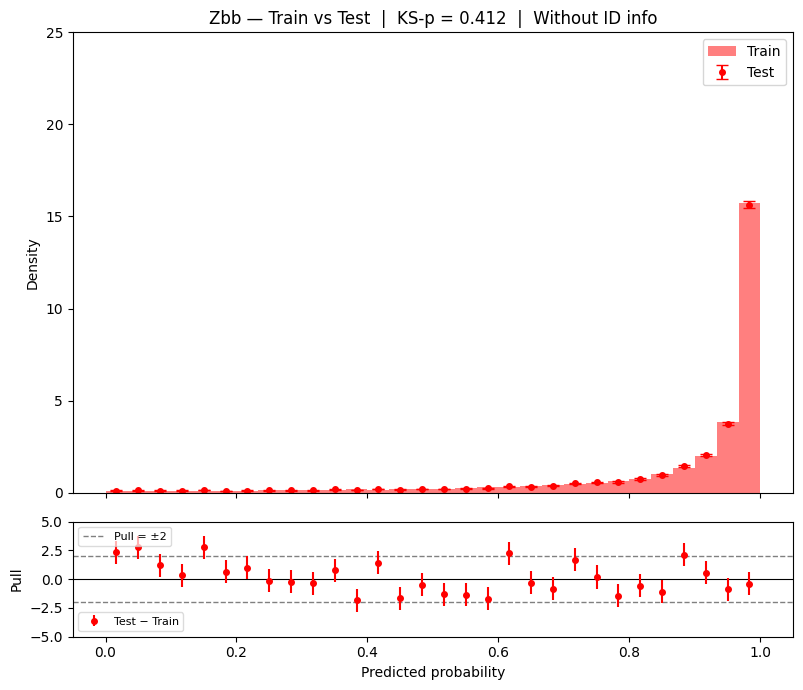

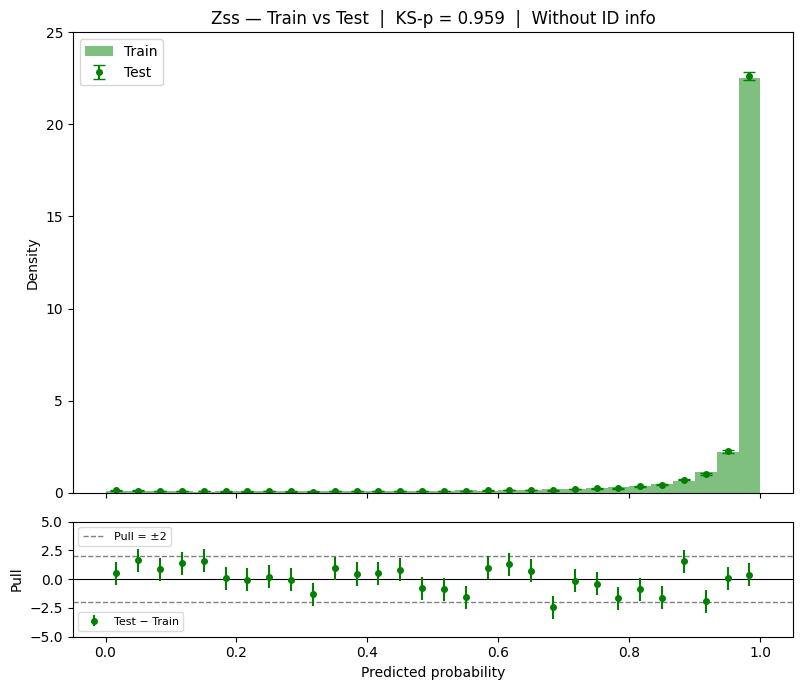

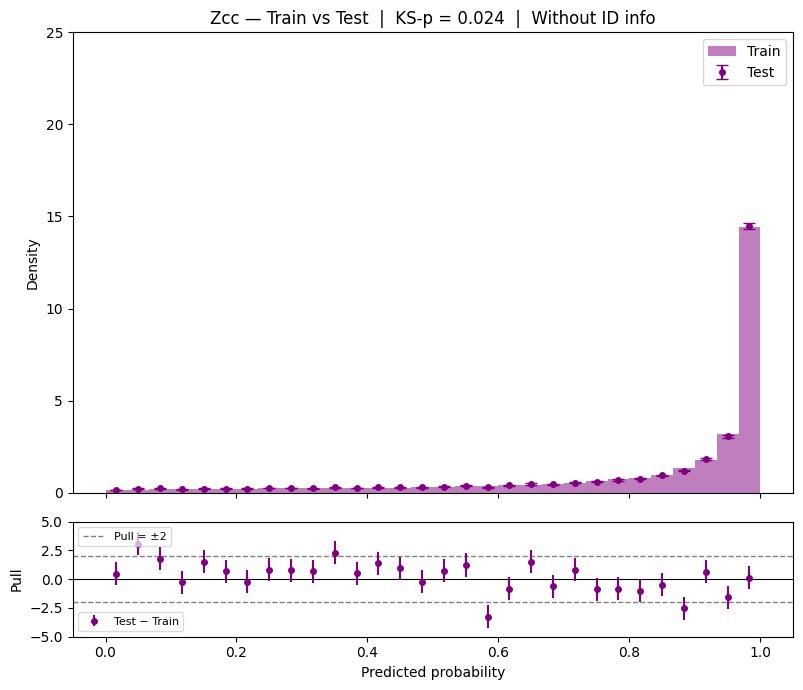

In [ ]:
def plot_flavor_histograms(pred_info, bins, color_dict, version):

    from scipy.stats import ks_2samp

    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_width   = bins[1] - bins[0]

    for flavor, info in pred_info.items():
        # ---------- data ----------
        tr = np.asarray(info['train_probs']).ravel()
        te = np.asarray(info['test_probs']).ravel()

        cnt_tr, _ = np.histogram(tr, bins=bins)
        cnt_te, _ = np.histogram(te, bins=bins)

        n_tr, n_te = len(tr), len(te)

        den_tr = cnt_tr / (n_tr * bin_width)
        den_te = cnt_te / (n_te * bin_width)

        err_tr = np.sqrt(cnt_tr) / (n_tr * bin_width)
        err_te = np.sqrt(cnt_te) / (n_te * bin_width)

        pull = (den_te - den_tr) / np.sqrt(err_te**2 + err_tr**2 + 1e-30)
        ks_p = ks_2samp(tr, te).pvalue

        # ---------- ----------
        col = color_dict.get(flavor, 'blue')
        fig, (ax_top, ax_bot) = plt.subplots(
            2, 1, figsize=(8, 7),
            gridspec_kw={'height_ratios': (4, 1)}, sharex=True)

        # —— density —— 
        ax_top.bar(bin_centers, den_tr,
                   width=bin_width, color=col, alpha=0.5, label='Train')
        ax_top.errorbar(bin_centers, den_te, yerr=err_te,
                        fmt='o', color=col, ms=4, capsize=4, label='Test')


        # ax_top.set_yscale('log')             
        ax_top.set_ylim(0, 25)                 

        ax_top.set_ylabel('Density')
        ax_top.set_title(f'{flavor} — Train vs Test  |  KS-p = {ks_p:.3f}  |  {version}')
        ax_top.legend()

        # —— Pull ——

        line_ref_pos = ax_bot.axhline( 2, color='grey', ls='--', lw=1.0)
        ax_bot.axhline(-2, color='grey', ls='--', lw=1.0)
        ax_bot.axhline( 0, color='k',   lw=0.8)

        eb = ax_bot.errorbar(bin_centers, pull, yerr=np.ones_like(pull),
                             fmt='o', color=col, ms=4, label='Test − Train')

        ax_bot.set_ylim(-5, 5)
        ax_bot.set_xlabel('Predicted probability')
        ax_bot.set_ylabel('Pull')

        # —— legend ——
        # 1) Pull = ±2 → 
        leg_ref = ax_bot.legend([line_ref_pos], ['Pull = ±2'],
                                loc='upper left', fontsize=8, framealpha=0.7)
        ax_bot.add_artist(leg_ref)       # 

        # 2) Test−Train pull → 
        ax_bot.legend(loc='lower left', fontsize=8, framealpha=0.7)

        plt.tight_layout()
        plt.show()


plot_flavor_histograms(pred_info_v2, bins, color_dict, "Without ID info")

<!-- import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

def plot_flavor_diagnostic(pred_info,           # 你准备好的字典
                           bins=np.linspace(0,1,51),
                           color_dict=None,
                           version='v1',
                           show_val=True):
    """
    为 pred_info 中的每一个 flavor 画一张两层图：
      • 上：train / (val) / test 的概率密度直方图（test 带 Poisson 误差），y 轴 log
      • 下：Pull = (test - train) / sqrt(sigma²_test + sigma²_train)
    """
    color_dict = color_dict or {}
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_width   = bins[1] - bins[0]

    for flavor, info in pred_info.items():
        # 拿到三组概率
        p_tr  = np.asarray(info['train_probs']).ravel()
        p_te  = np.asarray(info['test_probs']).ravel()
        p_val = np.asarray(info['val_probs']).ravel() if show_val else None

        n_tr, n_te = len(p_tr), len(p_te)

        # 直方图计数
        cnt_tr, _ = np.histogram(p_tr,  bins=bins)
        cnt_te, _ = np.histogram(p_te,  bins=bins)
        if show_val:
            cnt_val, _ = np.histogram(p_val, bins=bins)

        # 密度 (归一化到 ∫=1) 以及 Poisson 误差
        den_tr = cnt_tr / (n_tr * bin_width)
        den_te = cnt_te / (n_te * bin_width)

        err_tr = np.sqrt(cnt_tr) / (n_tr * bin_width)
        err_te = np.sqrt(cnt_te) / (n_te * bin_width)

        # Pull = (test-train)/σ_total
        pull = (den_te - den_tr) / np.sqrt(err_te**2 + err_tr**2 + 1e-30)

        # KS p-value（train vs test）
        p_ks = kstest(p_tr, p_te).pvalue

        # ---------- 画图 ----------
        col = color_dict.get(flavor, 'C0')
        fig, (ax_top, ax_bot) = plt.subplots(
            2, 1, figsize=(8, 7),
            gridspec_kw={'height_ratios': (3, 1)}, sharex=True)

        # -- 主图 --
        # 用 step 画 train，避免遮住
        ax_top.step(bin_centers, den_tr, where='mid', color=col,
                    lw=1.6, label='Train')
        ax_top.errorbar(bin_centers, den_te, yerr=err_te, fmt='o',
                        ms=4, color=col, capsize=3, label='Test')
        if show_val:
            den_val = cnt_val / (len(p_val) * bin_width)
            ax_top.step(bin_centers, den_val, where='mid',
                        color='grey', ls='--', lw=1.2, label='Val')

        ax_top.set_yscale('log')
        ax_top.set_ylim(top=max(den_tr.max(), den_te.max())*2)
        ax_top.set_ylabel('Density')
        ax_top.set_title(
            f'{flavor}  —  Train vs Test (KS-p = {p_ks:.3f})  |  {version}')
        ax_top.legend()

        # -- Pull 子图 --
        ax_bot.axhline(0, color='k', lw=0.8)
        ax_bot.errorbar(bin_centers, pull, yerr=np.ones_like(pull),
                        fmt='o', color=col, ms=4)
        ax_bot.set_ylim(-5, 5)
        ax_bot.set_xlabel('Predicted probability')
        ax_bot.set_ylabel('Pull')

        plt.tight_layout()
        plt.show()

bins = np.linspace(0, 1, 51)      # 50 个 bin
colors = {'Zbb': 'red', 'Zss': 'green', 'Zcc': 'purple'}

plot_flavor_diagnostic(pred_info_v2,
                       bins=bins,
                       color_dict=colors,
                       version='With ID info',
                       show_val=False) -->

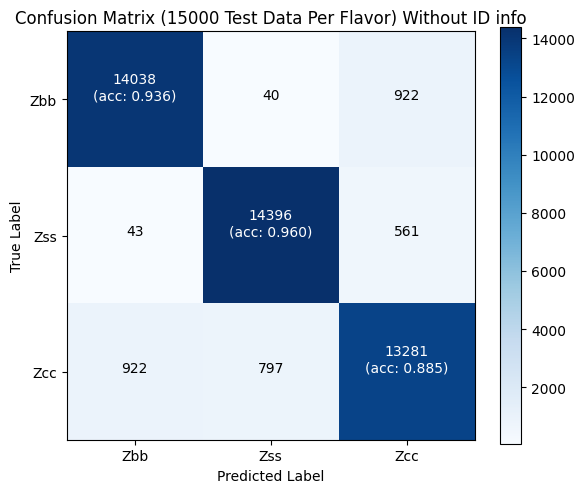

In [21]:
plot_confusion_matrix_from_pred_info(pred_info_v2, "Without ID info")

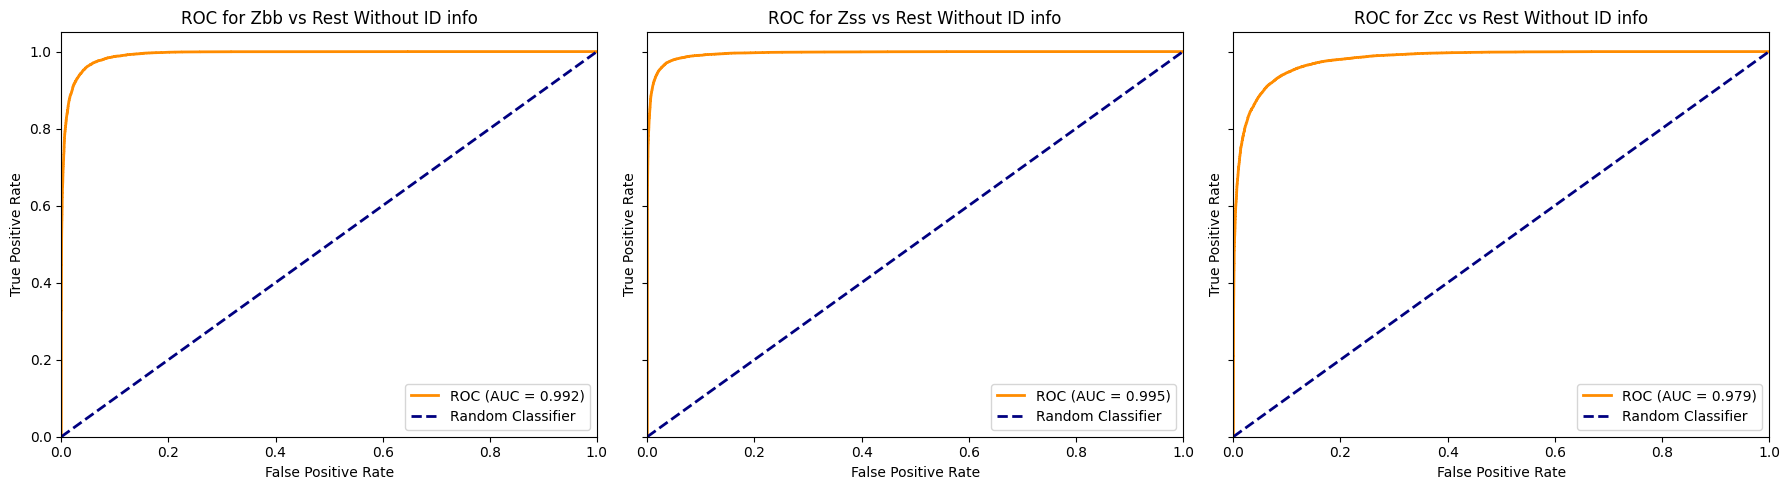

In [22]:
plot_roc_curves(pred_info_v2, flavor_map, version="Without ID info")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp  # 
import itertools

train_probs = model_v2.predict(train_dataset_v2, verbose=1)  # 
test_probs  = model_v2.predict(test_dataset_v2,  verbose=1)  # 


 40/293 ━━━━━━━━━━━━━━━━━━━━ 1:17 306ms/step

KeyboardInterrupt: 

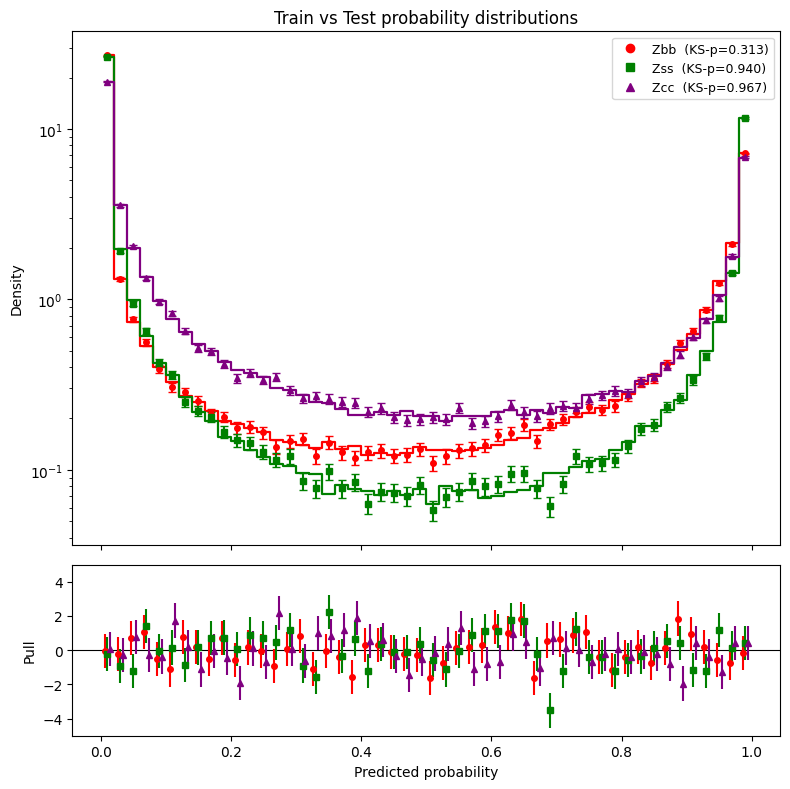

In [ ]:

# ------------- 2. plotting parameters ---------------
class_names = ['Zbb', 'Zss', 'Zcc']          
colors      = {'Zbb':'red', 'Zss':'green', 'Zcc':'purple'}
markers     = itertools.cycle(['o', 's', '^'])
bins        = np.linspace(0, 1, 51)          # 50 bin, Δx=0.02
bin_centers = 0.5 * (bins[1:] + bins[:-1])
bin_width   = bins[1] - bins[0]

Ntr, Nte = len(train_probs), len(test_probs)
shift = [-0.004, 0, 0.004]                   


fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(8, 8),
        gridspec_kw={'height_ratios': (3, 1)},
        sharex=True)

for idx, cname in enumerate(class_names):
    col = colors[cname]
    mk  = next(markers)


    cnt_tr, _ = np.histogram(train_probs[:, idx], bins=bins)
    cnt_te, _ = np.histogram(test_probs[:,  idx], bins=bins)


    den_tr = cnt_tr / (Ntr * bin_width)
    den_te = cnt_te / (Nte * bin_width)
    err_tr = np.sqrt(cnt_tr) / (Ntr * bin_width)
    err_te = np.sqrt(cnt_te) / (Nte * bin_width)


    ks_p = ks_2samp(train_probs[:, idx], test_probs[:, idx]).pvalue


    ax_top.step(bin_centers, den_tr, where='mid',
                color=col, lw=1.6)
    ax_top.errorbar(bin_centers, den_te, yerr=err_te,
                    fmt=mk, ms=4, capsize=3, color=col)


    ax_top.plot([], [], color=col, marker=mk, linestyle='',
                label=f'{cname}  (KS-p={ks_p:.3f})')


    pull = (den_te - den_tr) / np.sqrt(err_te**2 + err_tr**2 + 1e-30)
    if idx == 0:
        ax_bot.axhline(0, color='k', lw=0.8)
    ax_bot.errorbar(bin_centers + shift[idx], pull, yerr=np.ones_like(pull),
                    fmt=mk, ms=4, color=col)


ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.set_title('Train vs Test probability distributions')
ax_top.legend(fontsize=9, ncol=1)

ax_bot.set_ylim(-5, 5)
ax_bot.set_xlabel('Predicted probability')
ax_bot.set_ylabel('Pull')

plt.tight_layout()
plt.show()


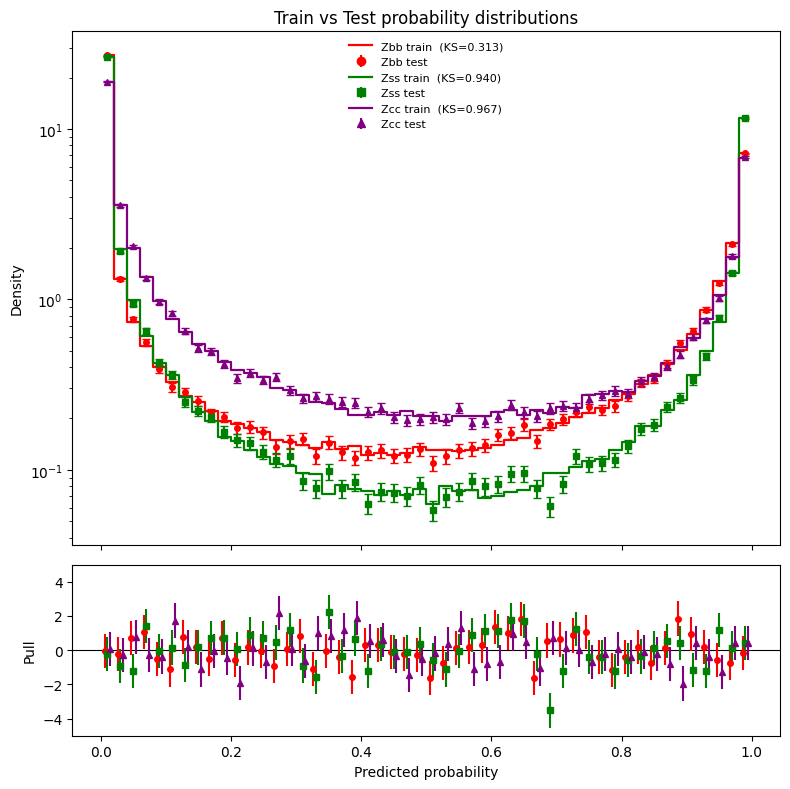

In [ ]:
# ---------- keep the original imports / data preparation ----------
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from matplotlib.lines import Line2D      # <-- for custom legend handles
import itertools

# (train_probs, test_probs, class_names, colors, markers, bins … already defined)

fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(8, 8),
        gridspec_kw={'height_ratios': (3, 1)},
        sharex=True)

ks_dict = {}                                 # <- store KS p for legend
marker_map = {'Zbb': 'o', 'Zss': 's', 'Zcc': '^'}  # fixed markers for legend

for idx, cname in enumerate(class_names):
    col = colors[cname]
    mk  = next(markers)

    cnt_tr, _ = np.histogram(train_probs[:, idx], bins=bins)
    cnt_te, _ = np.histogram(test_probs[:,  idx], bins=bins)

    den_tr = cnt_tr / (Ntr * bin_width)
    den_te = cnt_te / (Nte * bin_width)
    err_tr = np.sqrt(cnt_tr) / (Ntr * bin_width)
    err_te = np.sqrt(cnt_te) / (Nte * bin_width)

    ks_p = ks_2samp(train_probs[:, idx], test_probs[:, idx]).pvalue
    ks_dict[cname] = ks_p                      # <-- save p-value

    ax_top.step(bin_centers, den_tr, where='mid',
                color=col, lw=1.6)
    ax_top.errorbar(bin_centers, den_te, yerr=err_te,
                    fmt=mk, ms=4, capsize=3, color=col)

    pull = (den_te - den_tr) / np.sqrt(err_te**2 + err_tr**2 + 1e-30)
    if idx == 0:
        ax_bot.axhline(0, color='k', lw=0.8)
    ax_bot.errorbar(bin_centers + shift[idx], pull, yerr=np.ones_like(pull),
                    fmt=mk, ms=4, color=col)

ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.set_title('Train vs Test probability distributions')

ax_bot.set_ylim(-5, 5)
ax_bot.set_xlabel('Predicted probability')
ax_bot.set_ylabel('Pull')

# ---------- custom legend: 6 rows, with explicit error bars ----------
from matplotlib.lines import Line2D
from matplotlib.container import ErrorbarContainer

handles, labels = [], []
for cname in class_names:
    col = colors[cname]
    mk  = marker_map[cname]

    # ----- train (solid line) -----
    handles.append(Line2D([], [], color=col, lw=1.6))
    labels.append(f'{cname} train  (KS={ks_dict[cname]:.3f})')

    # ----- test (solid marker + error bar proxy) -----
    # create a dummy errorbar to get a proper ErrorbarContainer handle
    eb = ax_top.errorbar([], [], yerr=[[1], [1]],
                         fmt=mk, ms=6, mfc=col, mec=col,
                         color=col, capsize=3)
    handles.append(eb)
    labels.append(f'{cname} test')

ax_top.legend(handles, labels,
              fontsize=8, frameon=False, loc='upper center', ncol=1)


plt.tight_layout()
plt.show()


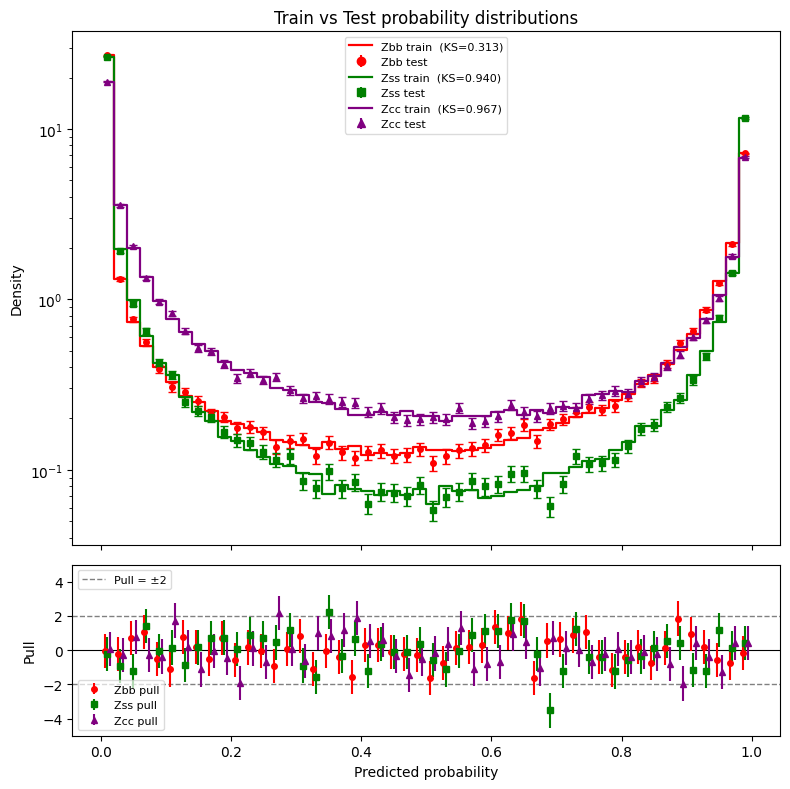

In [ ]:
# ---------- keep the original imports / data preparation ----------
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from matplotlib.lines import Line2D
from matplotlib.container import ErrorbarContainer
import itertools



fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(8, 8),
        gridspec_kw={'height_ratios': (3, 1)},
        sharex=True)

ks_dict = {}
marker_map = {'Zbb': 'o', 'Zss': 's', 'Zcc': '^'}

pull_handles, pull_labels = [], []          # 保存 pull 的图例

for idx, cname in enumerate(class_names):
    col = colors[cname]
    mk  = next(markers)

    cnt_tr, _ = np.histogram(train_probs[:, idx], bins=bins)
    cnt_te, _ = np.histogram(test_probs[:,  idx], bins=bins)

    den_tr = cnt_tr / (Ntr * bin_width)
    den_te = cnt_te / (Nte * bin_width)
    err_tr = np.sqrt(cnt_tr) / (Ntr * bin_width)
    err_te = np.sqrt(cnt_te) / (Nte * bin_width)

    ks_p           = ks_2samp(train_probs[:, idx], test_probs[:, idx]).pvalue
    ks_dict[cname] = ks_p

    # ---------- upper: density ----------
    ax_top.step(bin_centers, den_tr, where='mid',
                color=col, lw=1.6)
    ax_top.errorbar(bin_centers, den_te, yerr=err_te,
                    fmt=mk, ms=4, capsize=3, color=col)

    # ---------- lower: pull ----------
    pull = (den_te - den_tr) / np.sqrt(err_te**2 + err_tr**2 + 1e-30)
    if idx == 0:

        pull_line_pos = ax_bot.axhline( 2, color='grey', ls='--', lw=1.0)
        ax_bot.axhline(-2, color='grey', ls='--', lw=1.0)
        ax_bot.axhline( 0, color='k',   lw=0.8)

    eb = ax_bot.errorbar(bin_centers + shift[idx], pull,
                         yerr=np.ones_like(pull),
                         fmt=mk, ms=4, color=col, label=f'{cname} pull')

    pull_handles.append(eb)
    pull_labels .append(f'{cname} pull')

# ---------- style ----------
ax_top.set_yscale('log')
ax_top.set_ylabel('Density')
ax_top.set_title('Train vs Test probability distributions')

ax_bot.set_ylim(-5, 5)
ax_bot.set_xlabel('Predicted probability')
ax_bot.set_ylabel('Pull')

# ---------- legend for upper panel ----------
handles_top, labels_top = [], []
for cname in class_names:
    col = colors[cname]
    mk  = marker_map[cname]

    handles_top.append(Line2D([], [], color=col, lw=1.6))
    labels_top .append(f'{cname} train  (KS={ks_dict[cname]:.3f})')

    eb_proxy = ax_top.errorbar([], [], yerr=[[1], [1]],
                               fmt=mk, ms=6, mfc=col, mec=col,
                               color=col, capsize=3)
    handles_top.append(eb_proxy)
    labels_top .append(f'{cname} test')

ax_top.legend(handles_top, labels_top,
              fontsize=8, loc='upper center', ncol=1, framealpha=0.7)

# ---------- legends for pull panel ----------

leg_ref = ax_bot.legend([pull_line_pos], ['Pull = ±2'],
                        loc='upper left', fontsize=8, framealpha=0.7)
ax_bot.add_artist(leg_ref)   


ax_bot.legend(pull_handles, pull_labels,
              loc='lower left', fontsize=8, framealpha=0.7)

plt.tight_layout()
plt.show()
